In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

sns.set_style("whitegrid")
plt.rcParams["figure.facecolor"] = "white"
ACCENT = "#0071E3"
ACCENT_RED = "#FF3B30"
ACCENT_GREEN = "#34C759"

df = pd.read_csv(os.path.join("..", "data", "processed", "Processed_EV_Data.csv"))
print(f"Loaded {len(df)} rows x {len(df.columns)} columns")

Loaded 10000 rows x 32 columns


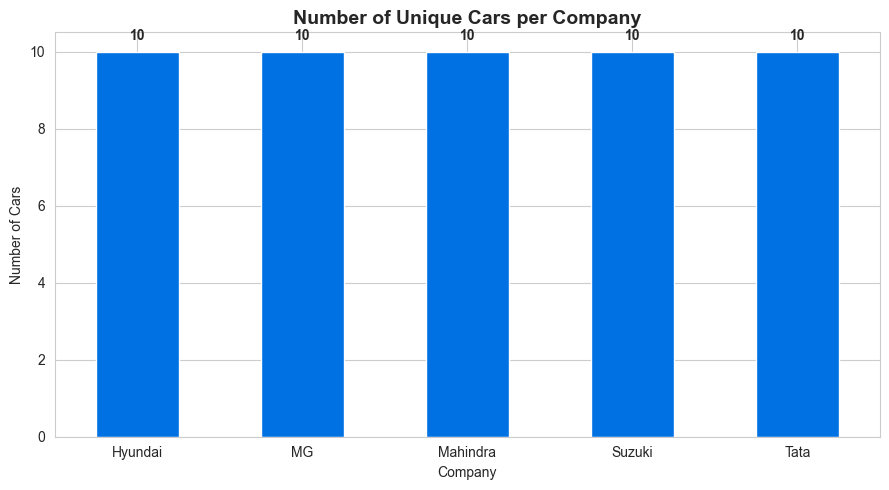

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
company_counts = df.groupby("Company")["Car_ID"].nunique().sort_values(ascending=False)
company_counts.plot(kind="bar", ax=ax, color=ACCENT)
ax.set_title("Number of Unique Cars per Company", fontsize=14, fontweight="bold")
ax.set_xlabel("Company")
ax.set_ylabel("Number of Cars")
plt.xticks(rotation=0)
for i, v in enumerate(company_counts):
    ax.text(i, v + 0.3, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

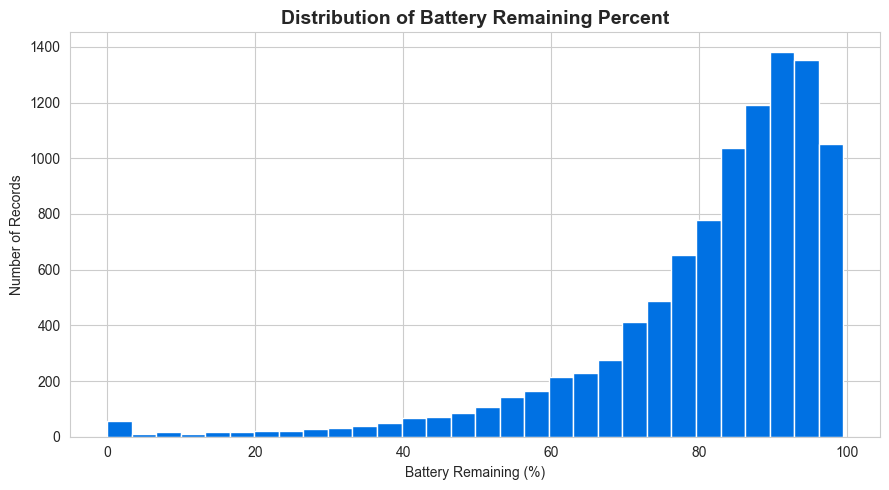

count    10000.000000
mean        81.460220
std         16.431157
min          0.000000
25%         75.850000
50%         86.115000
75%         92.570000
max         99.440000
Name: Battery_Remaining_Percent, dtype: float64


In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df["Battery_Remaining_Percent"], bins=30, color=ACCENT, edgecolor="white")
ax.set_title("Distribution of Battery Remaining Percent", fontsize=14, fontweight="bold")
ax.set_xlabel("Battery Remaining (%)")
ax.set_ylabel("Number of Records")
plt.tight_layout()
plt.show()

print(df["Battery_Remaining_Percent"].describe())

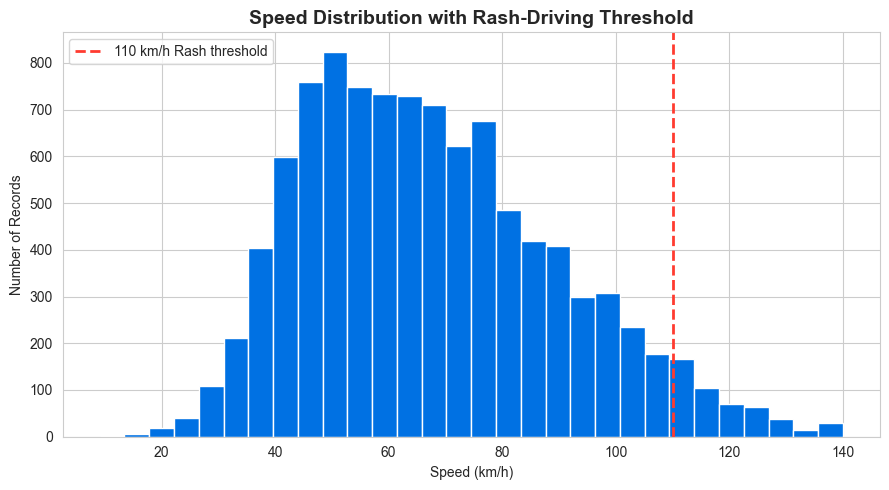

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df["Speed_kmph"], bins=30, color=ACCENT, edgecolor="white")
ax.axvline(110, color=ACCENT_RED, linestyle="--", linewidth=2, label="110 km/h Rash threshold")
ax.set_title("Speed Distribution with Rash-Driving Threshold", fontsize=14, fontweight="bold")
ax.set_xlabel("Speed (km/h)")
ax.set_ylabel("Number of Records")
ax.legend()
plt.tight_layout()
plt.show()

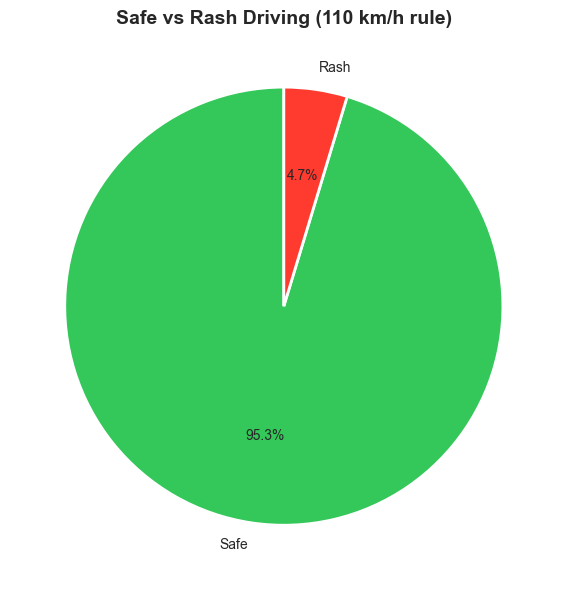

Driving_Style
Safe    9533
Rash     467
Name: count, dtype: int64


In [28]:
fig, ax = plt.subplots(figsize=(6, 6))
style_counts = df["Driving_Style"].value_counts()
colors = [ACCENT_GREEN if s == "Safe" else ACCENT_RED for s in style_counts.index]
ax.pie(style_counts.values, labels=style_counts.index, autopct="%1.1f%%",
       colors=colors, startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
ax.set_title("Safe vs Rash Driving (110 km/h rule)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(style_counts)

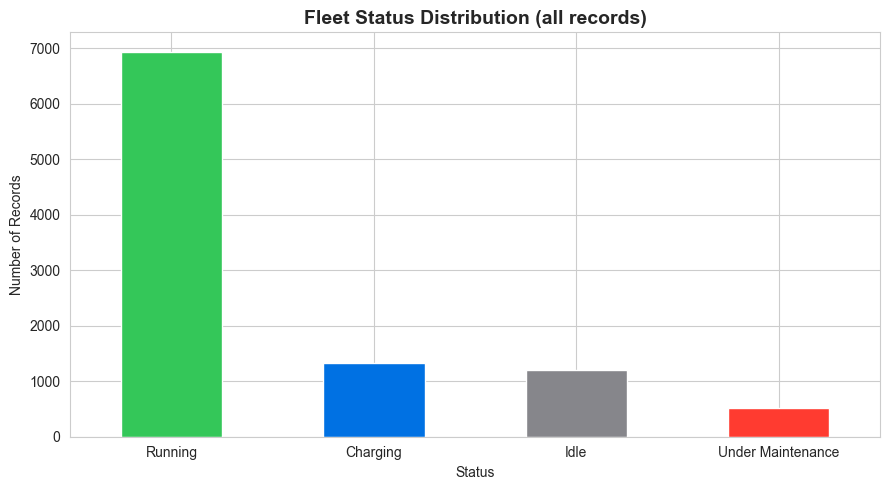

In [29]:
fig, ax = plt.subplots(figsize=(9, 5))
status_counts = df["Fleet_Status"].value_counts()
status_colors = {"Running": ACCENT_GREEN, "Charging": ACCENT, "Idle": "#86868B", "Under Maintenance": ACCENT_RED}
bar_colors = [status_colors.get(s, "#86868B") for s in status_counts.index]
status_counts.plot(kind="bar", ax=ax, color=bar_colors)
ax.set_title("Fleet Status Distribution (all records)", fontsize=14, fontweight="bold")
ax.set_xlabel("Status")
ax.set_ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

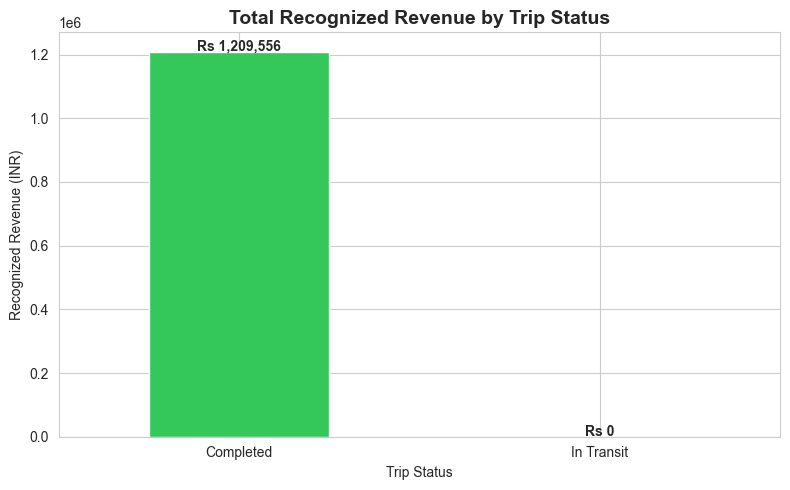

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))
revenue_by_status = df.groupby("Trip_Status")["Recognized_Revenue"].sum()
colors2 = [ACCENT_GREEN if s == "Completed" else ACCENT_RED for s in revenue_by_status.index]
revenue_by_status.plot(kind="bar", ax=ax, color=colors2)
ax.set_title("Total Recognized Revenue by Trip Status", fontsize=14, fontweight="bold")
ax.set_xlabel("Trip Status")
ax.set_ylabel("Recognized Revenue (INR)")
plt.xticks(rotation=0)
for i, v in enumerate(revenue_by_status):
    ax.text(i, v + 2000, f"Rs {v:,.0f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

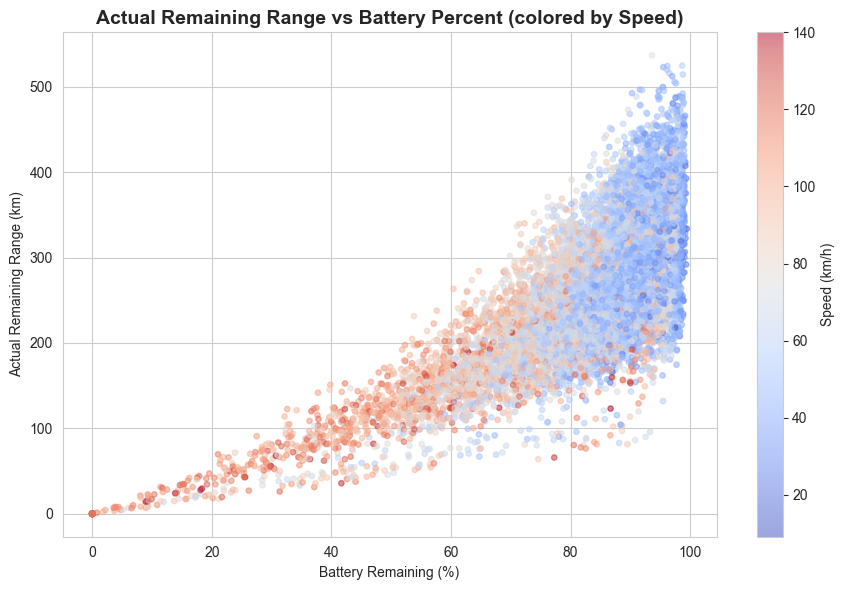

In [31]:
fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(df["Battery_Remaining_Percent"], df["Actual_Remaining_Range_km"],
                      c=df["Speed_kmph"], cmap="coolwarm", alpha=0.5, s=15)
ax.set_title("Actual Remaining Range vs Battery Percent (colored by Speed)", fontsize=14, fontweight="bold")
ax.set_xlabel("Battery Remaining (%)")
ax.set_ylabel("Actual Remaining Range (km)")
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Speed (km/h)")
plt.tight_layout()
plt.show()

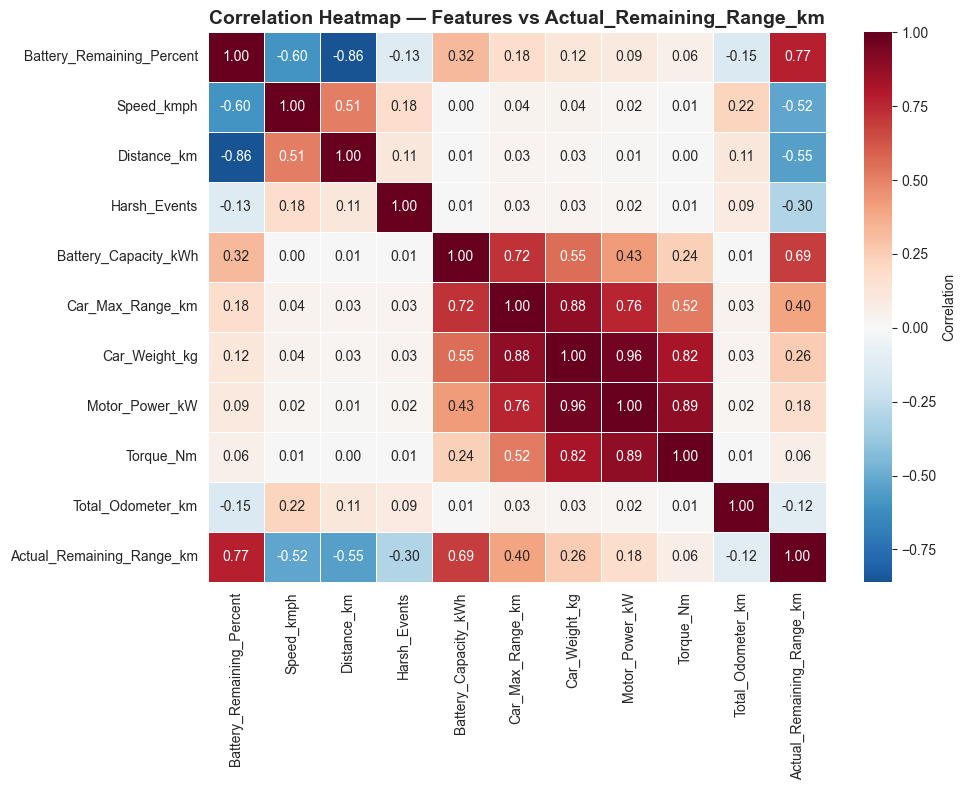

In [32]:
numeric_cols = ["Battery_Remaining_Percent", "Speed_kmph", "Distance_km", "Harsh_Events",
                 "Battery_Capacity_kWh", "Car_Max_Range_km", "Car_Weight_kg", "Motor_Power_kW",
                 "Torque_Nm", "Total_Odometer_km", "Actual_Remaining_Range_km"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            linewidths=0.5, cbar_kws={"label": "Correlation"})
ax.set_title("Correlation Heatmap — Features vs Actual_Remaining_Range_km", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

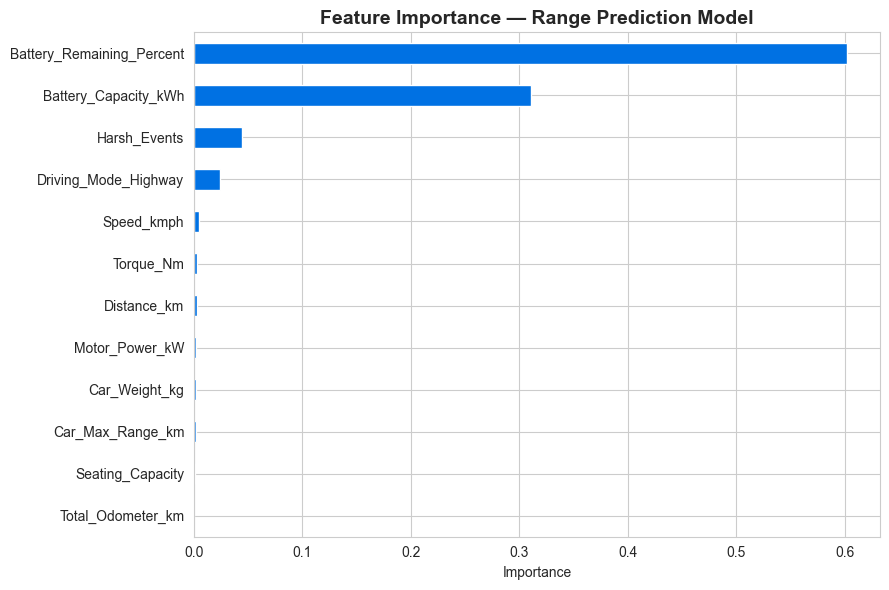

Battery_Remaining_Percent    0.602504
Battery_Capacity_kWh         0.310904
Harsh_Events                 0.044403
Driving_Mode_Highway         0.024309
Speed_kmph                   0.004378
Torque_Nm                    0.003244
Distance_km                  0.003105
Motor_Power_kW               0.002329
Car_Weight_kg                0.002195
Car_Max_Range_km             0.001709
Seating_Capacity             0.000604
Total_Odometer_km            0.000316
dtype: float64


In [33]:
MODEL_PATH = os.path.join("..", "src", "models", "range_predictor.pkl")
bundle = joblib.load(MODEL_PATH)
model = bundle["model"]
feature_columns = bundle["feature_columns"]

importance = pd.Series(model.feature_importances_, index=feature_columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
importance.plot(kind="barh", ax=ax, color=ACCENT)
ax.set_title("Feature Importance — Range Prediction Model", fontsize=14, fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print(importance.sort_values(ascending=False))

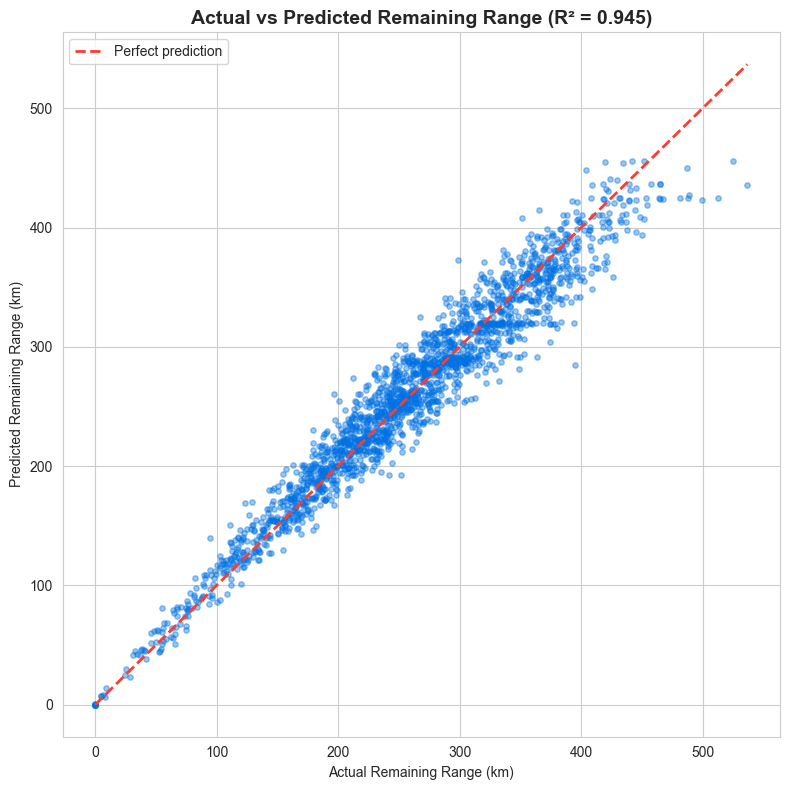

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

FEATURES = ["Battery_Remaining_Percent", "Speed_kmph", "Driving_Mode", "Distance_km",
            "Harsh_Events", "Battery_Capacity_kWh", "Car_Max_Range_km", "Car_Weight_kg",
            "Seating_Capacity", "Motor_Power_kW", "Torque_Nm", "Total_Odometer_km"]
TARGET = "Actual_Remaining_Range_km"

X = pd.get_dummies(df[FEATURES], columns=["Driving_Mode"], drop_first=True)
X = X.reindex(columns=feature_columns, fill_value=0)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
preds = model.predict(X_test)
r2 = r2_score(y_test, preds)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, preds, alpha=0.4, s=15, color=ACCENT)
lims = [0, max(y_test.max(), preds.max())]
ax.plot(lims, lims, color=ACCENT_RED, linestyle="--", linewidth=2, label="Perfect prediction")
ax.set_title(f"Actual vs Predicted Remaining Range (R² = {r2:.3f})", fontsize=14, fontweight="bold")
ax.set_xlabel("Actual Remaining Range (km)")
ax.set_ylabel("Predicted Remaining Range (km)")
ax.legend()
plt.tight_layout()
plt.show()

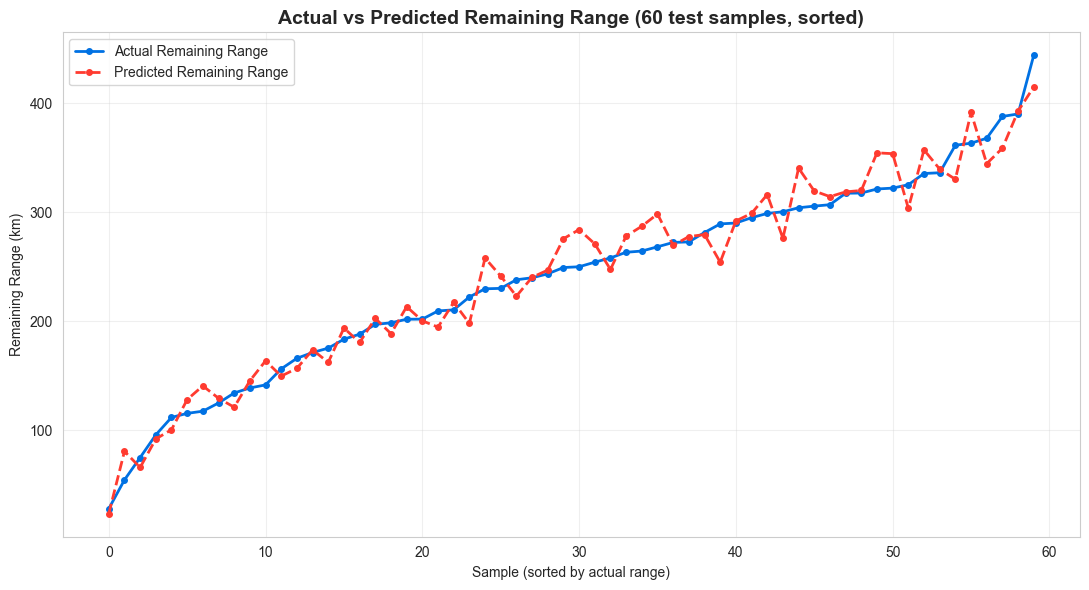

In [35]:
sample_size = 60
np.random.seed(42)
sample_idx = np.random.choice(len(y_test), size=sample_size, replace=False)

y_test_arr = y_test.values[sample_idx]
preds_arr = preds[sample_idx]

sort_order = np.argsort(y_test_arr)
y_sorted = y_test_arr[sort_order]
preds_sorted = preds_arr[sort_order]

fig, ax = plt.subplots(figsize=(11, 6))
x_axis = range(len(y_sorted))
ax.plot(x_axis, y_sorted, color=ACCENT, linewidth=2, marker='o', markersize=4, label='Actual Remaining Range')
ax.plot(x_axis, preds_sorted, color=ACCENT_RED, linewidth=2, marker='o', markersize=4, linestyle='--', label='Predicted Remaining Range')
ax.set_title("Actual vs Predicted Remaining Range (60 test samples, sorted)", fontsize=14, fontweight="bold")
ax.set_xlabel("Sample (sorted by actual range)")
ax.set_ylabel("Remaining Range (km)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

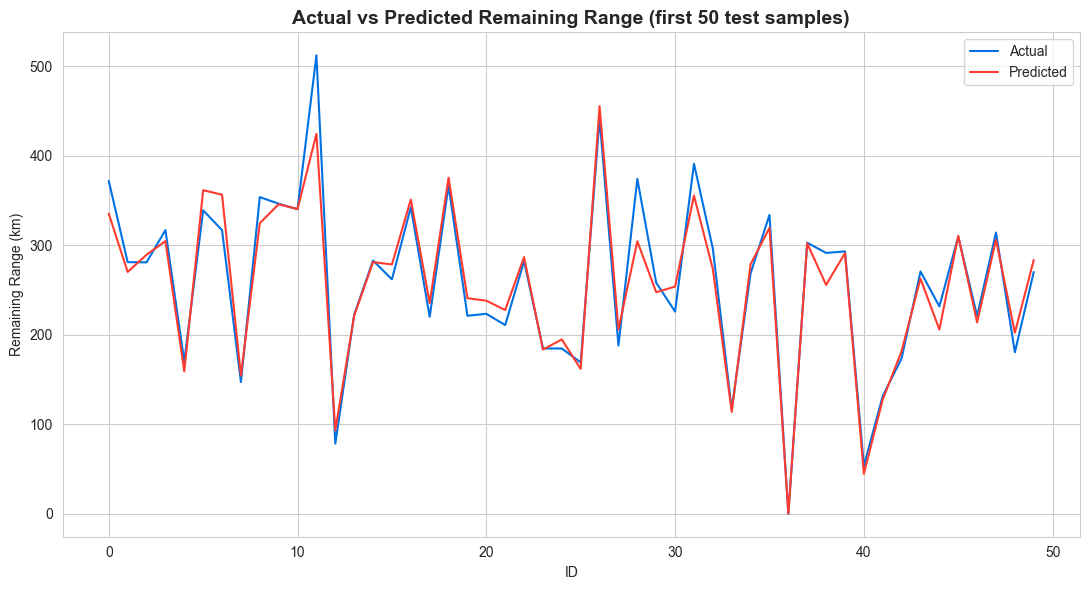

In [36]:
result = pd.DataFrame({
    "ID": range(len(y_test)),
    "actual_range_km": y_test.values,
    "predicted_range_km": preds,
})

fig, ax = plt.subplots(figsize=(11, 6))
sns.lineplot(x='ID', y='actual_range_km', data=result.head(50), label='Actual', color=ACCENT)
sns.lineplot(x='ID', y='predicted_range_km', data=result.head(50), label='Predicted', color=ACCENT_RED)
plt.title("Actual vs Predicted Remaining Range (first 50 test samples)", fontsize=14, fontweight="bold")
plt.xlabel("ID")
plt.ylabel("Remaining Range (km)")
plt.tight_layout()
plt.show()